# 05. 네이버 쇼핑 검색 에이전트

---

## 실습 목표

이 실습에서는 네이버 쇼핑 검색 API와 LLM을 LangGraph로 연결해 상품 추천 에이전트를 구성한다.

핵심 목표는 다음과 같다.

1. 자연어 쇼핑 요청을 LLM으로 분석한다.
2. 검색어, 가격 조건, 정렬 기준을 구조화한다.
3. 네이버 쇼핑 API로 상품을 검색한다.
4. 검색 결과가 부족하면 검색어를 재작성해 다시 검색한다.
5. 최종 상품 추천 리포트를 생성한다.

## 그래프 구조

```text
START
  ↓
요청분석
  ↓
상품검색
  ↓
결과평가
  ├─ 충분함 → 추천리포트 → END
  └─ 부족함 → 검색어재작성 → 상품검색
```

이 실습은 **외부 REST API 호출, LLM 기반 요청 분석, 조건부 Edge, 재검색 루프**를 함께 다루는 종합 실습이다.

---

## 사전 준비

### 1. 패키지 설치
```bash
uv add requests python-dotenv langchain-openai langchain-core langgraph grandalf
```

### 2. 네이버 개발자 API 키 발급

1. [네이버 개발자 센터](https://developers.naver.com) 접속 → 로그인
2. **Application 등록** → 애플리케이션 이름 입력
3. **사용 API**: `검색` 선택
4. **Client ID** 와 **Client Secret** 확인

### 3. `.env` 파일에 키 추가
```text
NAVER_CLIENT_ID=your_client_id
NAVER_CLIENT_SECRET=your_client_secret
```

> 네이버 검색 API는 **하루 25,000회** 무료 제공됩니다.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

In [2]:
# 환경 변수 확인
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
NAVER_CLIENT_ID = os.getenv("NAVER_CLIENT_ID")
NAVER_CLIENT_SECRET = os.getenv("NAVER_CLIENT_SECRET")

missing_keys = [
    key for key, value in {
        "OPENAI_API_KEY": OPENAI_API_KEY,
        "NAVER_CLIENT_ID": NAVER_CLIENT_ID,
        "NAVER_CLIENT_SECRET": NAVER_CLIENT_SECRET,
    }.items()
    if not value
]

if missing_keys:
    raise ValueError(
        "다음 환경 변수를 .env 파일에 설정해야 한다: "
        + ", ".join(missing_keys)
    )

print("환경 설정 완료")
print("OPENAI_API_KEY 설정 여부:", bool(OPENAI_API_KEY))
print("NAVER_CLIENT_ID 설정 여부:", bool(NAVER_CLIENT_ID))
print("NAVER_CLIENT_SECRET 설정 여부:", bool(NAVER_CLIENT_SECRET))

환경 설정 완료
OPENAI_API_KEY 설정 여부: True
NAVER_CLIENT_ID 설정 여부: True
NAVER_CLIENT_SECRET 설정 여부: True


In [3]:
import os
import re
import json
import requests
from html import unescape
from typing import TypedDict, List, Any, Dict

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("준비 완료")

준비 완료


---

## Step 1. 네이버 쇼핑 API 래퍼 함수

네이버 쇼핑 API는 HTTP GET 방식으로 호출한다.

| 파라미터 | 설명 | 값 |
|---|---|---|
| `query` | 검색어 | 문자열 |
| `display` | 결과 개수 | 1~100 |
| `sort` | 정렬 기준 | `sim`, `date`, `asc`, `dsc` |

정렬 기준은 다음과 같다.

| 값 | 의미 |
|---|---|
| `sim` | 정확도순 |
| `date` | 날짜순 |
| `asc` | 가격 낮은순 |
| `dsc` | 가격 높은순 |

이 실습에서는 `query`, `display`, `sort`만 사용한다.

In [4]:
def clean_html(text: str) -> str:
    """네이버 API 응답에 포함된 HTML 태그를 제거한다."""
    text = unescape(text or "")
    return re.sub(r"<[^>]+>", "", text).strip()


def search_naver_shopping(query: str, display: int = 10, sort: str = "sim") -> list[dict]:
    """
    네이버 쇼핑 API로 상품을 검색한다.

    query:
        네이버 쇼핑 검색어이다.
    display:
        가져올 검색 결과 개수이다. 네이버 API 기준 1~100 범위만 허용된다.
    sort:
        sim(정확도순), date(날짜순), asc(가격 낮은순), dsc(가격 높은순)을 사용한다.
    """
    query = query.strip()
    if not query:
        return []

    # display와 sort 값은 API 오류를 줄이기 위해 허용 범위로 보정한다.
    display = max(1, min(display, 100))
    if sort not in ("sim", "date", "asc", "dsc"):
        sort = "sim"

    url = "https://openapi.naver.com/v1/search/shop.json"
    headers = {
        "X-Naver-Client-Id": NAVER_CLIENT_ID,
        "X-Naver-Client-Secret": NAVER_CLIENT_SECRET,
    }
    params = {
        "query": query,
        "display": display,
        "start": 1,
        "sort": sort,
    }

    try:
        response = requests.get(url, headers=headers, params=params, timeout=10)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        raise RuntimeError(f"네이버 쇼핑 API 호출 실패: {e}") from e

    items = response.json().get("items", [])

    products = []
    for item in items:
        products.append({
            "title": clean_html(item.get("title", "")),
            "link": item.get("link", ""),
            "image": item.get("image", ""),
            "lprice": int(item.get("lprice", 0) or 0),
            "hprice": int(item.get("hprice", 0) or 0),
            "mall": item.get("mallName", ""),
            "brand": item.get("brand", ""),
            "maker": item.get("maker", ""),
            "category1": item.get("category1", ""),
            "category2": item.get("category2", ""),
            "category3": item.get("category3", ""),
            "category4": item.get("category4", ""),
        })

    return products


print("네이버 쇼핑 API 래퍼 함수 정의 완료")

네이버 쇼핑 API 래퍼 함수 정의 완료


In [5]:
# API 기본 테스트
# 실제 API 호출이므로 네이버 API 키가 설정되어 있어야 실행된다.

test_products = search_naver_shopping("무선 이어폰", display=5, sort="sim")

print(f"검색 결과: {len(test_products)}개\n")
for idx, product in enumerate(test_products, start=1):
    print(f"[{idx}] {product['title']}")
    print(f"    최저가: {product['lprice']:,}원")
    print(f"    쇼핑몰: {product['mall']}")
    print(f"    카테고리: {product['category1']} > {product['category2']}")
    print(f"    URL: {product['link'][:70]}...")
    print()

검색 결과: 5개

[1] NEW QCY 큐씨와이 AIR 초경량 가 성비 음질좋은 블루투스 무선 이어폰 오픈형
    최저가: 21,800원
    쇼핑몰: 비욘드퍼니싱
    카테고리: 디지털/가전 > 음향가전
    URL: https://smartstore.naver.com/main/products/12182776514...

[2] 블라우풍트 BLP-OE383
    최저가: 67,700원
    쇼핑몰: 네이버
    카테고리: 디지털/가전 > 음향가전
    URL: https://search.shopping.naver.com/catalog/53531535646...

[3] 베이스어스 BP1 PRO 노이즈캔슬링 이어폰
    최저가: 28,900원
    쇼핑몰: 네이버
    카테고리: 디지털/가전 > 음향가전
    URL: https://search.shopping.naver.com/catalog/57474367418...

[4] 로랜텍 커널형 버즈 무선 블루투스 이어폰 RSM-R510
    최저가: 19,800원
    쇼핑몰: 네이버
    카테고리: 디지털/가전 > 음향가전
    URL: https://search.shopping.naver.com/catalog/53530143052...

[5] [공식] 삼성 갤럭시 버즈4 프로 무선 블루투스 이어폰 SM-R640
    최저가: 359,000원
    쇼핑몰: 삼성공식파트너 엠디텍
    카테고리: 디지털/가전 > 음향가전
    URL: https://smartstore.naver.com/main/products/13104069397...



---

## Step 2. State 정의


LangGraph의 State는 그래프 전체에서 유지되는 공유 상태 객체이다.

이 실습의 State는 다음 정보를 관리한다.

| 필드 | 의미 |
|---|---|
| `request` | 사용자의 원본 쇼핑 요청이다. |
| `search_query` | 실제 네이버 쇼핑 API에 전달할 검색어이다. |
| `max_price` | 가격 상한선이다. 제한이 없으면 0이다. |
| `sort` | 정렬 기준이다. |
| `products` | 검색된 상품 목록이다. |
| `is_sufficient` | 검색 결과가 추천에 충분한지 나타낸다. |
| `feedback` | 평가 결과 또는 재검색 사유이다. |
| `recommendation` | 최종 추천 리포트이다. |
| `search_count` | 검색 노드 실행 횟수이다. |

In [6]:
MAX_SEARCH_COUNT = 3  # 최대 검색 횟수 (재검색 포함)

class ShoppingState(TypedDict):
    request:        str         # 사용자 원본 요청 (입력)
    search_query:   str         # 검색어 (분석/재작성 후)
    max_price:      int         # 가격 상한선 원 (0 = 제한 없음)
    sort:           str         # 정렬 기준: sim | asc | dsc
    products:       List[dict]  # 검색된 상품 목록
    is_sufficient:  bool        # 결과 충분 여부
    feedback:       str         # 사용자 피드백 (입력)
    recommendation: str         # 최종 추천 리포트 (출력)
    search_count:   int         # 재검색 횟수 (무한루프 방지)

print("ShoppingState 필드:", list(ShoppingState.__annotations__.keys()))
for field in ShoppingState.__annotations__:
    print("-", field)

ShoppingState 필드: ['request', 'search_query', 'max_price', 'sort', 'products', 'is_sufficient', 'feedback', 'recommendation', 'search_count']
- request
- search_query
- max_price
- sort
- products
- is_sufficient
- feedback
- recommendation
- search_count


---

## Step 3. LLM JSON 출력 보정 함수

LLM에게 JSON만 출력하라고 지시해도 실제 출력에 코드블록이 포함될 수 있다.

예를 들면 다음과 같은 형태가 나올 수 있다.

```text
```json
{"search_query": "무선 이어폰", "max_price": 50000, "sort": "asc"}
```
```

따라서 JSON 부분만 안전하게 추출하는 함수를 만든다.

In [7]:
def extract_json(text: str) -> dict[str, Any]:
    """LLM 출력에서 JSON 객체 부분만 추출해 dict로 변환한다."""
    text = text.strip()

    # ```json ... ``` 형태의 코드블록 제거
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    # 출력 안에서 가장 바깥 JSON 객체를 찾는다.
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"JSON 객체를 찾을 수 없다: {text}")

    return json.loads(match.group(0))


print("JSON 추출 함수 정의 완료")

JSON 추출 함수 정의 완료


---

## Step 4. 노드 정의

그래프에는 5개 노드가 있다.

| 노드 | 역할 |
|---|---|
| 요청분석 | 사용자의 자연어 요청을 검색 파라미터로 변환한다. |
| 상품검색 | 네이버 쇼핑 API를 호출하고 가격 조건을 적용한다. |
| 결과평가 | 추천 가능한 상품이 충분한지 판단한다. |
| 검색어재작성 | 결과가 부족하면 더 넓은 검색어로 바꾼다. |
| 추천리포트 | 검색 결과를 바탕으로 최종 추천 리포트를 작성한다. |

In [8]:
# 노드 1: 요청분석
analyze_prompt = ChatPromptTemplate.from_messages([
    ("system", """사용자의 쇼핑 요청을 분석해 아래 JSON 형식으로만 출력한다.

{{
  "search_query": "네이버 쇼핑에 적합한 검색어",
  "max_price": 가격상한선_정수,
  "sort": "sim" 또는 "date" 또는 "asc" 또는 "dsc"
}}

규칙:
- 가격 상한선이 없으면 "max_price"는 0으로 둔다.
- 저렴한 상품, 최저가, 가성비 요청이면 "sort"는 "asc"로 둔다.
- 최신 상품, 신상품 요청이면 "sort"는 "date"로 둔다.
- 높은 가격순을 명시적으로 요청하면 "sort"는 "dsc"로 둔다.
- 그 외에는 "sort"를 "sim"으로 둔다.
- JSON 외의 설명 문장은 출력하지 않는다."""),
    ("human", "{request}")
])

analyze_chain = analyze_prompt | llm | StrOutputParser()

In [9]:
def analyze_node(state: ShoppingState) -> dict:
    """사용자 요청에서 검색어, 가격 조건, 정렬 기준을 추출한다."""
    print(f"  [요청분석] 요청: {state['request']}")

    result = analyze_chain.invoke({"request": state["request"]})

    try:
        parsed = extract_json(result)
        search_query = str(parsed.get("search_query", state["request"])).strip()
        max_price = int(parsed.get("max_price", 0) or 0)
        sort = str(parsed.get("sort", "sim")).strip()

        if max_price < 0:
            max_price = 0
        if sort not in ("sim", "date", "asc", "dsc"):
            sort = "sim"
        if not search_query:
            search_query = state["request"]

    except Exception as e:
        print(f"  [요청분석] JSON 파싱 실패, 원본 요청을 검색어로 사용한다: {e}")
        search_query = state["request"]
        max_price = 0
        sort = "sim"

    price_text = f"{max_price:,}원 이하" if max_price else "제한 없음"
    print(f"  [요청분석] 검색어='{search_query}', 가격={price_text}, 정렬={sort}")

    return {
        "search_query": search_query,
        "max_price": max_price,
        "sort": sort,
    }

In [10]:
# 노드 2: 상품검색
def search_node(state: ShoppingState) -> dict:
    """네이버 쇼핑 API로 상품을 검색하고 가격 조건을 적용한다."""
    search_count = state.get("search_count", 0) + 1
    query = state["search_query"]
    sort = state.get("sort", "sim")

    print(f"  [상품검색 #{search_count}] 검색어='{query}', 정렬={sort}")

    # 가격 필터링 후에도 충분한 상품이 남도록 30개를 가져온다.
    products = search_naver_shopping(query, display=30, sort=sort)

    max_price = state.get("max_price", 0)
    if max_price > 0:
        before_count = len(products)
        products = [
            product for product in products
            if 0 < product["lprice"] <= max_price
        ]
        print(f"  [상품검색] 가격 필터: {before_count}개 → {len(products)}개")
    else:
        print(f"  [상품검색] 수집 상품 수: {len(products)}개")

    # 추천 리포트에는 상위 10개만 사용한다.
    return {
        "products": products[:10],
        "search_count": search_count,
    }

In [11]:
# 노드 3: 결과평가
MAX_SEARCH_COUNT = 3  # 최대 검색 횟수 (재검색 포함)
def evaluate_node(state: ShoppingState) -> dict:
    """검색 결과가 추천 리포트를 작성하기에 충분한지 판단한다."""
    products = state.get("products", [])
    search_count = state.get("search_count", 0)

    is_sufficient = len(products) >= 3

    if is_sufficient:
        feedback = "추천 가능한 상품이 3개 이상이다."
    elif search_count >= MAX_SEARCH_COUNT:
        feedback = "상품이 부족하지만 최대 검색 횟수에 도달해 추천 리포트를 작성한다."
    else:
        feedback = "상품이 부족하다. 검색어를 더 넓게 재작성한다."

    print(f"  [결과평가] 상품 수={len(products)}개, 충분 여부={is_sufficient}")
    print(f"  [결과평가] {feedback}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


In [12]:
# 노드 4: 검색어재작성
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """검색 결과가 부족하다.
원본 요청의 의도와 가격 조건을 유지하면서 네이버 쇼핑에서 더 잘 검색될 수 있는 넓은 검색어로 바꾼다.

규칙:
- 검색어만 출력한다.
- 문장형 설명을 출력하지 않는다.
- 너무 긴 검색어는 피한다.
- 브랜드명이 결과를 좁힌다면 일반 제품명으로 바꾼다."""),
    ("human", "원본 요청: {request}\n현재 검색어: {search_query}\n평가 피드백: {feedback}\n\n새 검색어:")
])

rewrite_chain = rewrite_prompt | llm | StrOutputParser()

In [13]:
def rewrite_node(state: ShoppingState) -> dict:
    """결과가 부족할 때 검색어를 더 넓게 재작성한다."""
    new_query = rewrite_chain.invoke({
        "request": state["request"],
        "search_query": state["search_query"],
        "feedback": state.get("feedback", ""),
    }).strip()

    # 혹시 따옴표나 불필요한 줄바꿈이 있으면 간단히 정리한다.
    new_query = new_query.strip().strip('"').strip("'")
    if not new_query:
        new_query = state["request"]

    print(f"  [검색어재작성] '{state['search_query']}' → '{new_query}'")
    return {"search_query": new_query}

In [14]:
# 노드 5: 추천리포트
recommend_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 쇼핑 검색 결과를 분석해 사용자에게 적합한 상품 추천 리포트를 작성한다.

작성 형식:

## 쇼핑 추천 리포트

### 추천 상품 TOP 3
| 순위 | 상품명 | 최저가 | 쇼핑몰 | 추천 이유 |
|---|---|---:|---|---|

### 구매 조언
- 가격대와 선택 기준을 2~3개 항목으로 정리한다.
- 검색 결과만 근거로 사용한다.
- 제공되지 않은 성능, 리뷰, 배송 조건은 추정하지 않는다."""),
    ("human", "요청: {request}\n검색어: {search_query}\n평가: {feedback}\n\n검색 상품 목록:\n{products}")
])

recommend_chain = recommend_prompt | llm | StrOutputParser()

In [15]:
def format_products(products: list[dict]) -> str:
    """상품 목록을 LLM 입력에 적합한 문자열로 변환한다."""
    if not products:
        return "검색된 상품이 없다."

    lines = []
    for idx, product in enumerate(products, start=1):
        category = " > ".join(
            value for value in [
                product.get("category1", ""),
                product.get("category2", ""),
                product.get("category3", ""),
            ]
            if value
        )
        lines.append(
            f"[{idx}] {product['title']}\n"
            f"최저가: {product['lprice']:,}원\n"
            f"쇼핑몰: {product['mall']}\n"
            f"브랜드: {product.get('brand') or '미상'}\n"
            f"카테고리: {category or '미상'}\n"
            f"링크: {product['link']}"
        )

    return "\n\n".join(lines)


In [16]:
def recommend_node(state: ShoppingState) -> dict:
    """검색된 상품을 바탕으로 최종 추천 리포트를 생성한다."""
    print("  [추천리포트] 생성 중")

    products = state.get("products", [])
    if not products:
        recommendation = (
            "## 쇼핑 추천 리포트\n\n"
            "검색 조건에 맞는 상품을 찾지 못했다.\n"
            "검색어를 더 일반적인 제품명으로 바꾸거나 가격 조건을 완화해야 한다."
        )
        return {"recommendation": recommendation}

    products_text = format_products(products[:5])

    recommendation = recommend_chain.invoke({
        "request": state["request"],
        "search_query": state["search_query"],
        "feedback": state.get("feedback", ""),
        "products": products_text,
    })

    print("  [추천리포트] 완료")
    return {"recommendation": recommendation}


print("노드 정의 완료")

노드 정의 완료


---

## Step 5. 라우팅 함수와 그래프 구성

`결과평가` 노드 이후에는 조건부 Edge를 사용한다.

분기 규칙은 다음과 같다.

1. 검색 결과가 충분하면 `추천리포트`로 이동한다.
2. 검색 결과가 부족하지만 최대 검색 횟수에 도달하면 `추천리포트`로 이동한다.
3. 검색 결과가 부족하고 재검색 가능하면 `검색어재작성`으로 이동한다.

`path_map`을 명시하면 그래프 시각화에서 조건부 분기가 더 명확하게 표시된다.

In [17]:
# ── 라우팅 함수 ──────────────────────────────────────────────
def decide_after_evaluate(state: ShoppingState) -> str:
    """평가 결과에 따라 추천 진행 또는 검색어 재작성 결정"""
    if state["is_sufficient"]:
        print("  [결정] 결과 충분 → 추천리포트")
        return "추천리포트"
    elif state.get("search_count", 0) >= MAX_SEARCH_COUNT:
        print(f"  [결정] {MAX_SEARCH_COUNT}회 재시도 초과 → 추천리포트 강제 진행")
        return "추천리포트"
    else:
        print("  [결정] 상품 부족 → 검색어 재작성")
        return "검색어재작성"


# ── 그래프 조립 ──────────────────────────────────────────────
builder = StateGraph(ShoppingState)

# 노드 등록
builder.add_node("요청분석",    analyze_node)
builder.add_node("상품검색",    search_node)
builder.add_node("결과평가",    evaluate_node)
builder.add_node("검색어재작성", rewrite_node)
builder.add_node("추천리포트",  recommend_node)

# 기본 실행 흐름 엣지 연결
builder.add_edge(START, "요청분석")
builder.add_edge("요청분석", "상품검색")
builder.add_edge("상품검색", "결과평가")

# 조건부 엣지: 평가 결과 → 추천 또는 재작성(루프)
builder.add_conditional_edges(
    "결과평가", 
    decide_after_evaluate,
    {
        "추천리포트": "추천리포트",
        "검색어재작성": "검색어재작성",
    },
)

# 재검색 루프
builder.add_edge("검색어재작성", "상품검색")  # 루프: 재작성 → 다시 검색

# 종료
builder.add_edge("추천리포트",   END)

shopping_app = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


---

## Step 6. 그래프 시각화

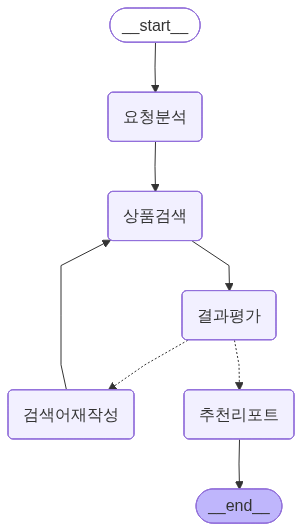

In [18]:
def show_graph(app):
    """그래프를 Mermaid 이미지로 출력하고, 실패하면 ASCII로 출력한다."""
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


show_graph(shopping_app)

---

## Step 7. 실행 테스트

In [19]:
def initial_state(request: str) -> ShoppingState:
    """그래프 실행에 필요한 초기 State를 만든다."""
    return {
        "request": request,
        "search_query": "",
        "max_price": 0,
        "sort": "sim",
        "products": [],
        "is_sufficient": False,
        "feedback": "",
        "recommendation": "",
        "search_count": 0,
    }


def run_shopping_agent(request: str):
    """쇼핑 요청을 받아 상품 추천 리포트를 생성한다."""
    print("\n" + "=" * 70)
    print(f"요청: {request}")
    print("=" * 70)

    result = shopping_app.invoke(initial_state(request))

    print(
        f"\n[검색어: '{result['search_query']}' | 정렬: {result['sort']} | "
        f"검색 횟수: {result['search_count']}회 | 수집 상품: {len(result['products'])}개]"
    )
    print("\n" + result["recommendation"])

    return result

In [20]:
# 테스트 1: 일반 요청
result_1 = run_shopping_agent("무선 이어폰 추천해줘")


요청: 무선 이어폰 추천해줘
  [요청분석] 요청: 무선 이어폰 추천해줘
  [요청분석] 검색어='무선 이어폰', 가격=제한 없음, 정렬=sim
  [상품검색 #1] 검색어='무선 이어폰', 정렬=sim
  [상품검색] 수집 상품 수: 30개
  [결과평가] 상품 수=10개, 충분 여부=True
  [결과평가] 추천 가능한 상품이 3개 이상이다.
  [결정] 결과 충분 → 추천리포트
  [추천리포트] 생성 중
  [추천리포트] 완료

[검색어: '무선 이어폰' | 정렬: sim | 검색 횟수: 1회 | 수집 상품: 10개]

## 쇼핑 추천 리포트

### 추천 상품 TOP 3
| 순위 | 상품명 | 최저가 | 쇼핑몰 | 추천 이유 |
|---|---|---:|---|---|
| 1 | 로랜텍 커널형 버즈 무선 블루투스 이어폰 RSM-R510 | 19,800원 | 네이버 | 가장 저렴한 가격으로 기본적인 무선 이어폰 기능을 제공하며, 가성비가 뛰어남. |
| 2 | NEW QCY 큐씨와이 AIR 초경량 | 21,800원 | 비욘드퍼니싱 | 초경량 디자인으로 편안한 착용감을 제공하며, 음질이 좋고 가격대비 성능이 우수함. |
| 3 | 베이스어스 BP1 PRO 노이즈캔슬링 이어폰 | 28,900원 | 네이버 | 노이즈 캔슬링 기능이 있어 외부 소음을 차단할 수 있으며, 가격대비 성능이 좋음. |

### 구매 조언
- **가격대**: 추천 상품들은 19,800원에서 28,900원 사이로, 가성비를 중시하는 사용자에게 적합합니다.
- **기능**: 기본적인 무선 이어폰 기능 외에도 노이즈 캔슬링 기능이 필요한 경우 베이스어스를 고려할 수 있습니다.
- **디자인**: 로랜텍은 커널형으로 귀에 잘 맞고, QCY는 초경량으로 장시간 착용 시 편안함을 제공합니다. 사용자의 취향에 따라 선택할 수 있습니다.


In [21]:
# 테스트 3: 정렬 조건 포함 요청
run_shopping_agent("가장 저렴한 기계식 키보드 알려줘")


요청: 가장 저렴한 기계식 키보드 알려줘
  [요청분석] 요청: 가장 저렴한 기계식 키보드 알려줘
  [요청분석] 검색어='기계식 키보드', 가격=제한 없음, 정렬=asc
  [상품검색 #1] 검색어='기계식 키보드', 정렬=asc
  [상품검색] 수집 상품 수: 30개
  [결과평가] 상품 수=10개, 충분 여부=True
  [결과평가] 추천 가능한 상품이 3개 이상이다.
  [결정] 결과 충분 → 추천리포트
  [추천리포트] 생성 중
  [추천리포트] 완료

[검색어: '기계식 키보드' | 정렬: asc | 검색 횟수: 1회 | 수집 상품: 10개]

## 쇼핑 추천 리포트

### 추천 상품 TOP 3
| 순위 | 상품명 | 최저가 | 쇼핑몰 | 추천 이유 |
|---|---|---:|---|---|
| 1 | 기계식 키보드 LED 전구 3mm 무변형 발광다이오드 | 70원 | 케이씨샵 | 가격이 가장 저렴하지만, 키보드가 아닌 조명 관련 상품입니다. |
| 2 | QSENN 큐센 민트V1 축 5핀 리니어 기계식 키보드 스위치 (1개) | 90원 | 왓키 WHATKEY | 기계식 키보드의 스위치로, 저렴한 가격에 기계식 키보드의 느낌을 경험할 수 있습니다. |
| 3 | QSENN 큐센 퍼플V1 축 5핀 택타일 기계식 키보드 스위치 (1개) | 90원 | 왓키 WHATKEY | 민트V1과 동일한 가격으로, 다른 타입의 스위치를 원하시는 분에게 적합합니다. |

### 구매 조언
- **가격대**: 추천 상품들은 모두 100원 이하로 매우 저렴합니다. 특히, 스위치 상품은 기계식 키보드의 성능을 좌우하는 중요한 요소입니다.
- **선택 기준**: 
  - **스위치 타입**: 리니어(민트V1)와 택타일(퍼플V1) 중 선택할 수 있으며, 개인의 취향에 따라 다르게 선택할 수 있습니다.
  - **용도**: LED 전구는 키보드와는 관련이 없으므로, 실제 기계식 키보드를 원하신다면 스위치 상품을 선택하는 것이 좋습니다.


{'request': '가장 저렴한 기계식 키보드 알려줘',
 'search_query': '기계식 키보드',
 'max_price': 0,
 'sort': 'asc',
 'products': [{'title': '기계식 키보드 LED 전구 3mm 무변형 발광다이오드 ikbc 개등 아이스블루 둥근머리 칠색 슬로플래시 하이라이트',
   'link': 'https://kc-global.co.kr/product/detail.html?product_no=1386756&cate_no=2326&display_group=1&utm_source=naver&utm_medium=shopping&utm_campaign=knowledge_shopping&mkt_in=Y&ghost_mall_id=naver&ref=naver_open',
   'image': 'https://shopping-phinf.pstatic.net/main_3802319/38023195445.1.jpg',
   'lprice': 70,
   'hprice': 0,
   'mall': '케이씨샵',
   'brand': '',
   'maker': '',
   'category1': '가구/인테리어',
   'category2': '인테리어소품',
   'category3': '조명',
   'category4': 'LED모듈'},
  {'title': 'QSENN 큐센 민트V1 축 5핀 리니어 기계식 키보드 스위치 (1개)',
   'link': 'https://smartstore.naver.com/main/products/11859324312',
   'image': 'https://shopping-phinf.pstatic.net/main_8940383/89403834906.jpg',
   'lprice': 90,
   'hprice': 0,
   'mall': '왓키 WHATKEY',
   'brand': 'QSENN',
   'maker': 'QSENN',
   'category1': '디지털/가전',


In [22]:
# stream(): 단계별 실행 과정 추적 + 최종 추천 결과 출력
print("=== stream()으로 단계별 실행 추적 ===")
print(f"{'단계':<5} {'노드':<10} {'출력 요약':<50}")
print("-" * 68)

step = 0
final_recommendation = ""

for event in shopping_app.stream({
    "request":        "10만원 이하 프리미엄 노이즈캔슬링 헤드폰",
    "search_query":   "",
    "max_price":      0,
    "sort":           "sim",
    "products":       [],
    "is_sufficient":  False,
    "feedback":       "",
    "recommendation": "",
    "search_count":   0,
}):
    step += 1
    node_name = list(event.keys())[0]
    output    = event[node_name]

    if "search_query" in output and "max_price" in output:
        summary = f"검색어='{output['search_query']}', 최대={output['max_price']:,}원"

    elif "products" in output:
        summary = f"{len(output['products'])}개 상품 수집"

    elif "is_sufficient" in output:
        summary = f"충분 여부 = {output['is_sufficient']}"

    elif "search_query" in output:
        summary = f"재작성 → '{output['search_query']}'"

    elif "recommendation" in output:
        final_recommendation = output["recommendation"]
        summary = "추천 리포트 생성 완료"

    else:
        summary = str(output)[:50]

    print(f"{step:<5} {node_name:<10} {summary:<50}")


print("\n" + "=" * 70)
print("최종 추천 결과")
print("=" * 70)

if final_recommendation:
    print(final_recommendation)
else:
    print("추천 결과가 생성되지 않았다.")

=== stream()으로 단계별 실행 추적 ===
단계    노드         출력 요약                                             
--------------------------------------------------------------------
  [요청분석] 요청: 10만원 이하 프리미엄 노이즈캔슬링 헤드폰
  [요청분석] 검색어='프리미엄 노이즈캔슬링 헤드폰', 가격=100,000원 이하, 정렬=asc
1     요청분석       검색어='프리미엄 노이즈캔슬링 헤드폰', 최대=100,000원                
  [상품검색 #1] 검색어='프리미엄 노이즈캔슬링 헤드폰', 정렬=asc
  [상품검색] 가격 필터: 30개 → 30개
2     상품검색       10개 상품 수집                                         
  [결과평가] 상품 수=10개, 충분 여부=True
  [결과평가] 추천 가능한 상품이 3개 이상이다.
  [결정] 결과 충분 → 추천리포트
3     결과평가       충분 여부 = True                                      
  [추천리포트] 생성 중
  [추천리포트] 완료
4     추천리포트      추천 리포트 생성 완료                                      

최종 추천 결과
## 쇼핑 추천 리포트

### 추천 상품 TOP 3
| 순위 | 상품명 | 최저가 | 쇼핑몰 | 추천 이유 |
|---|---|---:|---|---|
| 1 | [대여] QCY H2 PRO 블루투스 헤드셋 헤드폰 | 900원 | 퀀슘 | 저렴한 가격으로 프리미엄 노이즈캔슬링 기능을 제공하는 블루투스 헤드셋. |
| 2 | [대여] 소니 CH520 무선 헤드폰 렌탈 | 900원 | 퀀슘 | 유명 브랜드 소니의 제품으로, 신뢰할 수 있는 품질과 성능을 기대할 수 있음. |
| 3 | 무선이어폰노이즈캔슬링

---

## 핵심 정리

```python
# 1. 네이버 쇼핑 API 호출
def search_naver_shopping(query: str, display: int = 10, sort: str = "sim") -> list[dict]:
    url = "https://openapi.naver.com/v1/search/shop.json"
    headers = {
        "X-Naver-Client-Id": NAVER_CLIENT_ID,
        "X-Naver-Client-Secret": NAVER_CLIENT_SECRET,
    }
    params = {
        "query": query,
        "display": display,
        "start": 1,
        "sort": sort,
    }

    response = requests.get(url, headers=headers, params=params, timeout=10)
    response.raise_for_status()

    return response.json()["items"]


# 2. LLM으로 자연어 요청을 구조화한다.
def analyze_node(state: ShoppingState) -> dict:
    result = analyze_chain.invoke({"request": state["request"]})
    parsed = extract_json(result)

    return {
        "search_query": parsed["search_query"],
        "max_price": parsed.get("max_price", 0),
        "sort": parsed.get("sort", "sim"),
    }


# 3. 검색 결과가 부족하면 조건부 Edge로 검색어재작성 노드로 이동한다.
def decide_after_evaluate(state: ShoppingState) -> str:
    if state["is_sufficient"]:
        return "추천리포트"

    if state["search_count"] >= MAX_SEARCH_ATTEMPTS:
        return "추천리포트"

    return "검색어재작성"


builder.add_conditional_edges(
    "결과평가",
    decide_after_evaluate,
    {
        "추천리포트": "추천리포트",
        "검색어재작성": "검색어재작성",
    },
)


# 4. 재검색 루프
builder.add_edge("검색어재작성", "상품검색")
```
- 노드 설명
  
| 노드 | 역할 |
|---|---|
| 요청분석 | 사용자의 자연어 쇼핑 요청을 검색어, 가격 조건, 정렬 기준으로 변환한다. |
| 상품검색 | 네이버 쇼핑 API를 호출하고 가격 조건을 적용한다. |
| 결과평가 | 추천 가능한 상품이 충분한지 판단한다. |
| 검색어재작성 | 결과가 부족할 때 LLM으로 더 넓은 검색어를 생성한다. |
| 추천리포트 | 검색된 상품을 바탕으로 최종 추천 리포트를 작성한다. |

- State 필드 설명

| State 필드 | 의미 |
|---|---|
| `request` | 사용자가 입력한 원본 쇼핑 요청이다. |
| `search_query` | 네이버 쇼핑 API에 전달되는 현재 검색어이다. |
| `max_price` | 가격 상한선이다. 제한이 없으면 0이다. |
| `sort` | 검색 결과 정렬 기준이다. |
| `products` | 검색과 가격 필터링을 거친 상품 목록이다. |
| `is_sufficient` | 검색 결과가 추천에 충분한지 나타낸다. |
| `feedback` | 결과평가 노드가 남긴 판단 근거이다. |
| `recommendation` | 최종 추천 리포트이다. |
| `search_count` | 상품검색 노드가 실행된 횟수이다. |

이 실습은 LangGraph에서 **외부 쇼핑 API 호출, LLM 기반 요청 분석, 조건부 분기, 재검색 루프, 최종 추천 리포트 생성**을 하나의 그래프로 구성하는 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
요청분석
  ↓
상품검색
  ↓
결과평가
  ├─ 충분함 → 추천리포트 → END
  └─ 부족함 → 검색어재작성 → 상품검색
```

이 구조에서 가장 중요한 부분은 다음 세 가지이다.

1. `요청분석` 노드는 자연어 요청을 API 호출에 필요한 구조화 파라미터로 변환한다.
2. `결과평가` 노드는 상품 수와 검색 횟수를 기준으로 다음 노드를 결정한다.
3. 조건부 Edge와 재검색 루프를 통해 검색 결과가 부족할 때 자동으로 검색어를 바꾸고 다시 검색한다.